# v12_bt_vs_live.py

Auto-generated from `notebooks/v12_bt_vs_live.py`.

Live: 12000 rows, ts 0-99900


BT slice: 12000 rows, ts 0-99900


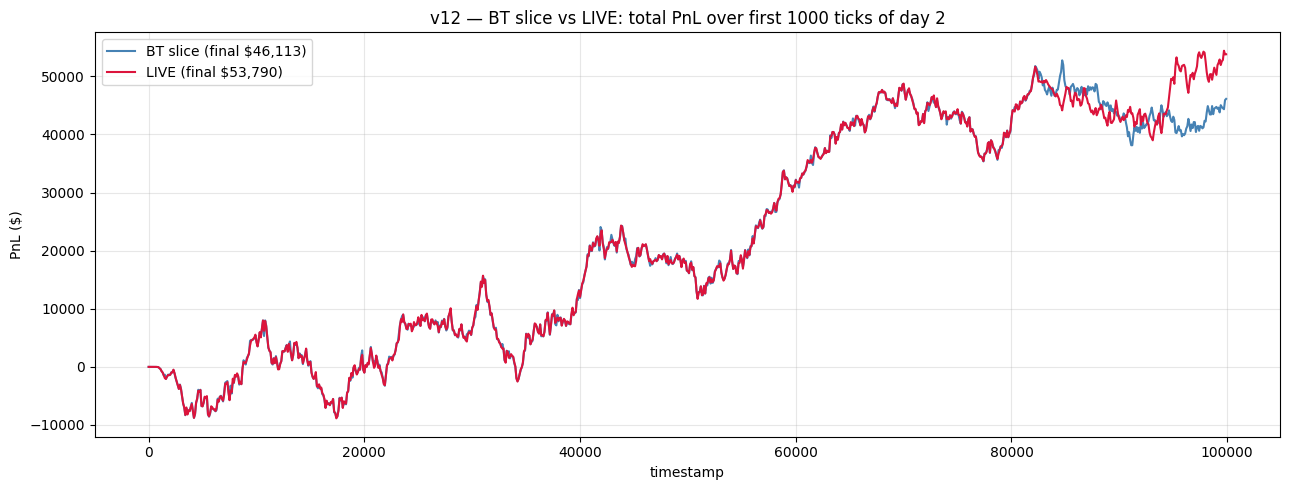

                     BT slice          LIVE
product                                    
HYDROGEL_PACK          8598.0   8557.625000
VELVETFRUIT_EXTRACT    8454.0  10191.625000
VEV_5000               9246.0  10980.152344
VEV_5100               8746.0  10675.812500
VEV_5200               7037.0   8514.738281
VEV_5300               4032.0   4869.583008

Totals: BT=46,113  LIVE=53,790  ratio=1.17x


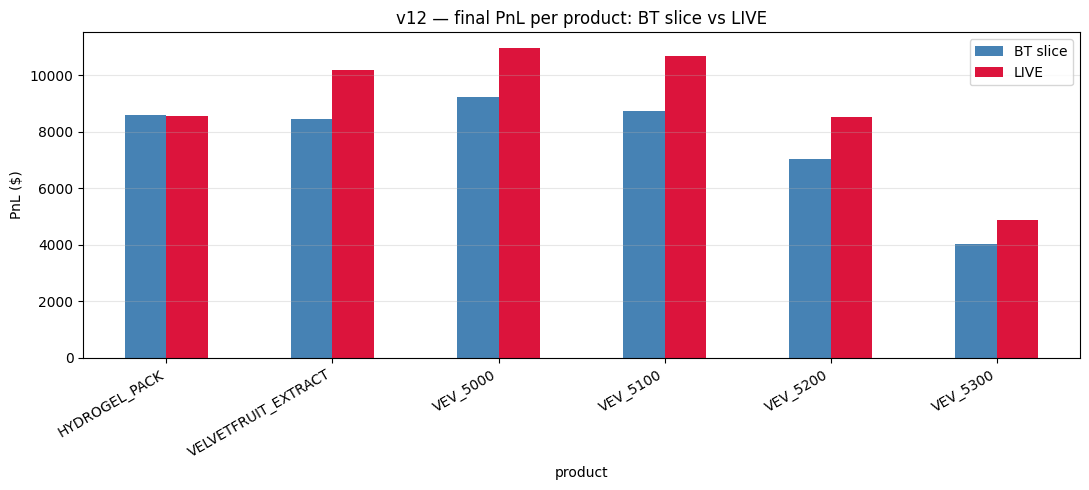

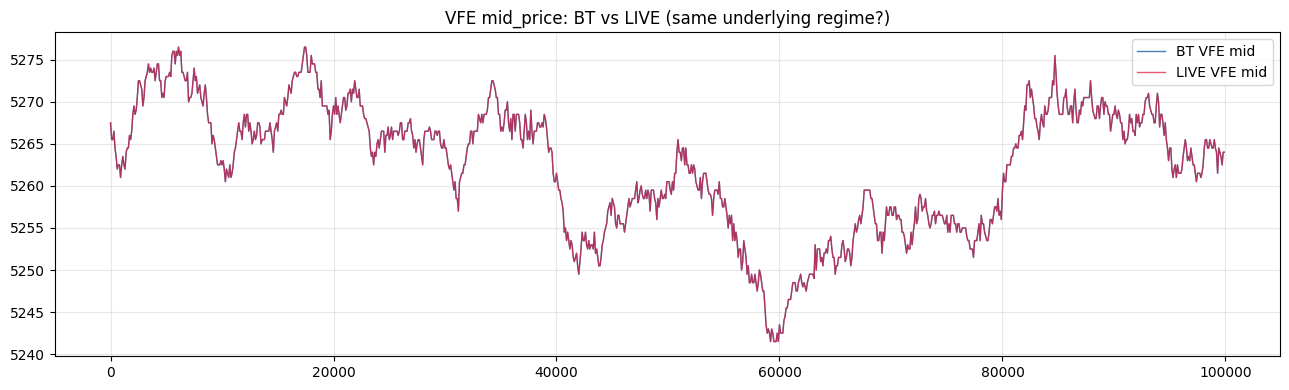

In [1]:
# %% [markdown]
# # v12 — BT day-2 first-1000-tick vs LIVE portal
# Side-by-side: did BT predict what actually happened live?
#
# - LIVE: data/live_logs/v12/478289.log (PnL $53,790)
# - BT slice: re-run v12 on day 2, slice first 1000 ticks (=ts 0-99900)

# %%
import json, io, subprocess, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
LIVE_LOG = ROOT / "data/live_logs/v12/478289.log"
TRADER = ROOT / "docs/round_3/strategies/snapshots/v12_trader.py"

# %%
# --- Parse LIVE log ---
live_data = json.load(open(LIVE_LOG))
live_df = pd.read_csv(io.StringIO(live_data["activitiesLog"]), sep=";")
print(f"Live: {len(live_df)} rows, ts {live_df.timestamp.min()}-{live_df.timestamp.max()}")

# %%
# --- Run BT on day 2 only and parse ---
out = subprocess.run(
    [str(ROOT / "venv/bin/prosperity4btest"), "cli", str(TRADER), "3-2",
     "--merge-pnl", "--no-progress"],
    capture_output=True, text=True, cwd=ROOT,
)
log_match = re.search(r"Successfully saved backtest results to (\S+\.log)", out.stdout)
bt_log = ROOT / log_match.group(1)
bt_text = bt_log.read_text()
csv_block = bt_text.split("Activities log:")[1].split("Trade History:")[0].strip()
bt_df = pd.read_csv(io.StringIO(csv_block), sep=";")
# Keep only first 1000 ticks (= portal slice)
bt_slice = bt_df[bt_df.timestamp <= 99900].copy()
print(f"BT slice: {len(bt_slice)} rows, ts {bt_slice.timestamp.min()}-{bt_slice.timestamp.max()}")

# %%
# --- Total PnL trajectory ---
def total_curve(df):
    return df.groupby("timestamp")["profit_and_loss"].sum()

bt_total = total_curve(bt_slice)
live_total = total_curve(live_df)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bt_total.index, bt_total.values, label=f"BT slice (final ${bt_total.iloc[-1]:,.0f})", lw=1.5, color="steelblue")
ax.plot(live_total.index, live_total.values, label=f"LIVE (final ${live_total.iloc[-1]:,.0f})", lw=1.5, color="crimson")
ax.set_title("v12 — BT slice vs LIVE: total PnL over first 1000 ticks of day 2")
ax.set_xlabel("timestamp")
ax.set_ylabel("PnL ($)")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# --- Per-product final PnL bar chart ---
bt_final = bt_slice[bt_slice.timestamp == bt_slice.timestamp.max()][["product", "profit_and_loss"]].set_index("product")["profit_and_loss"]
live_final = live_df[live_df.timestamp == live_df.timestamp.max()][["product", "profit_and_loss"]].set_index("product")["profit_and_loss"]

# Only show products we trade
traded = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT", "VEV_5000", "VEV_5100", "VEV_5200", "VEV_5300"]
compare = pd.DataFrame({"BT slice": bt_final.reindex(traded), "LIVE": live_final.reindex(traded)})
print(compare)
print(f"\nTotals: BT={compare['BT slice'].sum():,.0f}  LIVE={compare['LIVE'].sum():,.0f}  ratio={compare['LIVE'].sum()/compare['BT slice'].sum():.2f}x")

ax = compare.plot.bar(figsize=(11, 5), color=["steelblue", "crimson"])
ax.set_title("v12 — final PnL per product: BT slice vs LIVE")
ax.set_ylabel("PnL ($)")
ax.grid(alpha=0.3, axis="y")
ax.axhline(0, color="black", lw=0.5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# %%
# --- VFE mid: BT vs LIVE (same regime?) ---
bt_vfe = bt_slice[bt_slice["product"] == "VELVETFRUIT_EXTRACT"][["timestamp", "mid_price"]].set_index("timestamp")["mid_price"]
live_vfe = live_df[live_df["product"] == "VELVETFRUIT_EXTRACT"][["timestamp", "mid_price"]].set_index("timestamp")["mid_price"]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(bt_vfe.index, bt_vfe.values, label="BT VFE mid", lw=1, color="steelblue")
ax.plot(live_vfe.index, live_vfe.values, label="LIVE VFE mid", lw=1, color="crimson", alpha=0.7)
ax.set_title("VFE mid_price: BT vs LIVE (same underlying regime?)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Verdict
# - If LIVE total > BT slice total: NOT overfit (BT was conservative)
# - If per-product ratios are similar: model generalized; no single product is doing all the work
# - If VFE mid lines overlap: same underlying regime — a fair comparison
